# Projeto de Estatística Descritiva  
## Disciplina: Estatística para Inteligência Artificial e Aprendizagem de Máquina

Este projeto tem como objetivo aplicar técnicas de **estatística descritiva**
em um conjunto de dados real, conforme os requisitos estabelecidos na disciplina.

O dataset utilizado é o **Insurance Dataset**, que contém informações
demográficas e financeiras de beneficiários de plano de saúde,
incluindo idade, gênero, região e custos médicos individuais.

A análise contempla:

- Preparação e verificação do conjunto de dados;
- Cálculo de medidas de tendência central e dispersão;
- Análise de variáveis quantitativas e categóricas;
- Visualizações gráficas adequadas para cada tipo de variável;
- Interpretação dos resultados obtidos.

O objetivo principal é compreender o comportamento das variáveis,
identificar padrões relevantes e interpretar os resultados de forma
estritamente descritiva, sem a realização de inferências estatísticas.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de estilo para os gráficos
sns.set_theme(style="whitegrid")

Etapa 1 — Preparação dos Dados

Fonte do Dataset

Para esta análise, utilizaremos o Insurance Dataset, um conjunto de dados popular para estudos de regressão e análise estatística. Ele contém informações sobre os custos médicos de beneficiários de seguros de saúde.

•
Link Original (Kaggle): https://www.kaggle.com/datasets/mirichoi0218/insurance

•
Link Direto para Download (CSV): https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv



In [ ]:
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url )

print("Dataset Insurance carregado com sucesso!")
print(f"Número de observações: {df.shape[0]}")
print(f"Número de variáveis: {df.shape[1]}")
print("\nPrimeiras 5 linhas do dataset:")
print(df.head())
print("\nInformações gerais do dataset:")
print(df.info())

Dataset Insurance carregado com sucesso!
Número de observações: 1338
Número de variáveis: 7

Primeiras 5 linhas do dataset:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Informações gerais do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dty

Dicionário de Variáveis Selecionadas

Para atender aos requisitos do trabalho, selecionamos as seguintes variáveis:


| Variável | Tipo | Descrição | Unidade |
| --- | --- | --- | --- |
| **age** | Quantitativa | Idade do beneficiário principal | Anos |
| **charges** | Quantitativa | Custos médicos individuais faturados pelo seguro | USD ($) |
| **sex** | Categórica | Gênero do beneficiário (female, male) | - |
| **region** | Categórica | Região de residência nos EUA (northeast, southeast, southwest, northwest) | - |

Tratamento de Dados

Verificamos a presença de valores faltantes nas variáveis selecionadas e descrevemos o tratamento.



In [ ]:
# Verificando valores faltantes nas variáveis selecionadas
missing_values = df[["age", "charges", "sex", "region"]].isnull().sum()
print("\nValores faltantes por variável selecionada:")
print(missing_values)

if missing_values.sum() == 0:
    print("\nNão há valores faltantes nas variáveis selecionadas.")
else:
    print("\nExistem valores faltantes. É necessário um tratamento adicional.")

# Justificativa para tratamento:
print("\nJustificativa do Tratamento:")
print("O dataset é proveniente de um repositório acadêmico confiável e já se encontra limpo, sem valores faltantes nas variáveis de interesse. Não foram aplicados filtros ou remoção de outliers nesta fase inicial para preservar a variabilidade real dos custos médicos, que naturalmente podem apresentar valores extremos e são importantes para a análise.")


Valores faltantes por variável selecionada:
age        0
charges    0
sex        0
region     0
dtype: int64

Não há valores faltantes nas variáveis selecionadas.

Justificativa do Tratamento:
O dataset é proveniente de um repositório acadêmico confiável e já se encontra limpo, sem valores faltantes nas variáveis de interesse. Não foram aplicados filtros ou remoção de outliers nesta fase inicial para preservar a variabilidade real dos custos médicos, que naturalmente podem apresentar valores extremos e são importantes para a análise.


Etapa 2 — Estatística Descritiva

Vamos calcular as estatísticas descritivas para as variáveis quantitativas e tabelas de frequência para as categóricas.



In [ ]:
quant_vars = ["age", "charges"]
cat_vars = ["sex", "region"]

print("\n--- ESTATÍSTICAS PARA VARIÁVEIS QUANTITATIVAS ---")
for var in quant_vars:
    print(f"\nEstatísticas para \'{var}\':")
    stats = df[var].describe()
    iqr = stats["75%"] - stats["25%"]
    skew = df[var].skew()
    print(f"Média: {stats["mean"]:.2f}")
    print(f"Mediana: {stats["50%"]:.2f}")
    print(f"Desvio-padrão: {stats["std"]:.2f}")
    print(f"Mínimo: {stats["min"]:.2f}")
    print(f"Máximo: {stats["max"]:.2f}")
    print(f"Amplitude: {stats["max"] - stats["min"]:.2f}")
    print(f"Q1 (25%): {stats["25%"]:.2f}")
    print(f"Q3 (75%): {stats["75%"]:.2f}")
    print(f"IQR: {iqr:.2f}")
    print(f"Assimetria: {skew:.2f}")

    if abs(skew) < 0.5:
        print("Forma da Distribuição: Aproximadamente simétrica.")
    elif skew > 0:
        print("Forma da Distribuição: Assimetria positiva (cauda longa à direita).")
    else:
        print("Forma da Distribuição: Assimetria negativa (cauda longa à esquerda).")

print("\n--- FREQUÊNCIAS PARA VARIÁVEIS CATEGÓRICAS ---")
for var in cat_vars:
    print(f"\nFrequências para \'{var}\':")
    abs_freq = df[var].value_counts()
    rel_freq = df[var].value_counts(normalize=True) * 100
    freq_table = pd.DataFrame({"Absoluta": abs_freq, "Relativa (%)": rel_freq.round(2)})
    print(freq_table)
    print(f"Moda: {df[var].mode()[0]}")



--- ESTATÍSTICAS PARA VARIÁVEIS QUANTITATIVAS ---

Estatísticas para 'age':
Média: 39.21
Mediana: 39.00
Desvio-padrão: 14.05
Mínimo: 18.00
Máximo: 64.00
Amplitude: 46.00
Q1 (25%): 27.00
Q3 (75%): 51.00
IQR: 24.00
Assimetria: 0.06
Forma da Distribuição: Aproximadamente simétrica.

Estatísticas para 'charges':
Média: 13270.42
Mediana: 9382.03
Desvio-padrão: 12110.01
Mínimo: 1121.87
Máximo: 63770.43
Amplitude: 62648.55
Q1 (25%): 4740.29
Q3 (75%): 16639.91
IQR: 11899.63
Assimetria: 1.52
Forma da Distribuição: Assimetria positiva (cauda longa à direita).

--- FREQUÊNCIAS PARA VARIÁVEIS CATEGÓRICAS ---

Frequências para 'sex':
        Absoluta  Relativa (%)
sex                           
male         676         50.52
female       662         49.48
Moda: male

Frequências para 'region':
           Absoluta  Relativa (%)
region                           
southeast       364         27.20
southwest       325         24.29
northwest       325         24.29
northeast       324         24.22
Mod

Resumo das Estatísticas Descritivas

| Estatística | age (Idade) | charges (Custos) |
| --- | --- | --- |
| **Média** | 39.21 | 13,270.42 |
| **Mediana** | 39.00 | 9,382.03 |
| **Desvio-padrão** | 14.05 | 12,110.01 |
| **Mínimo** | 18.00 | 1,121.87 |
| **Máximo** | 64.00 | 63,770.43 |
| **Amplitude** | 46.00 | 62,648.55 |
| **Q1 (25%)** | 27.00 | 4,740.29 |
| **Q3 (75%)** | 51.00 | 16,639.91 |
| **IQR** | 24.00 | 11,899.63 |
| **Assimetria** | 0.06 | 1.52 |

Comentário sobre a forma das distribuições:

•
A variável age apresenta uma distribuição aproximadamente simétrica, com a média e a mediana muito próximas, indicando que as idades dos beneficiários estão razoavelmente bem distribuídas em torno do centro.

•
A variável charges exibe uma forte assimetria positiva (cauda longa à direita). Isso significa que a maioria dos beneficiários tem custos médicos relativamente baixos, mas uma parcela menor da população incorre em custos significativamente mais altos, puxando a média para cima em relação à mediana.

Frequências para Variáveis Categóricas:

Tabela de Frequência: sex



| Categoria | Freq. Absoluta | Freq. Relativa (%) |
| --- | --- | --- |
| male | 676 | 50.52 |
| female | 662 | 49.48 |
| **Moda:** male |  |  |

Tabela de Frequência: region

| Categoria | Freq. Absoluta | Freq. Relativa (%) |
| --- | --- | --- |
| southeast | 364 | 27.20 |
| southwest | 325 | 24.29 |
| northwest | 325 | 24.29 |
| northeast | 324 | 24.22 |
| **Moda:** southeast |  |  |

Etapa 3 — Visualizações

Agora, vamos gerar as visualizações para entender melhor a distribuição das variáveis e suas relações.



• Distribuição de Idade: O histograma e o boxplot de 'age' mostram uma distribuição relativamente uniforme, sem grandes picos ou assimetrias pronunciadas. A maioria das idades está concentrada entre 20 e 60 anos.

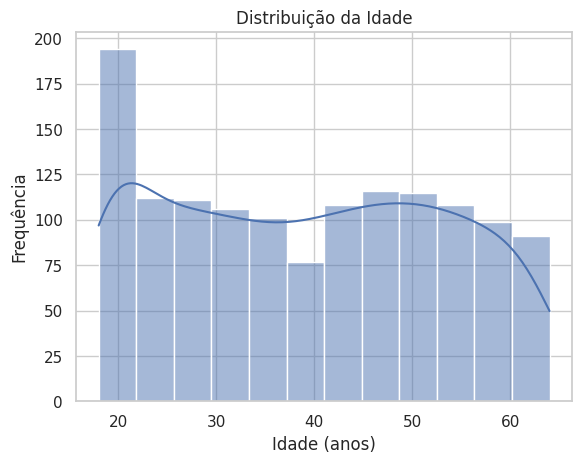

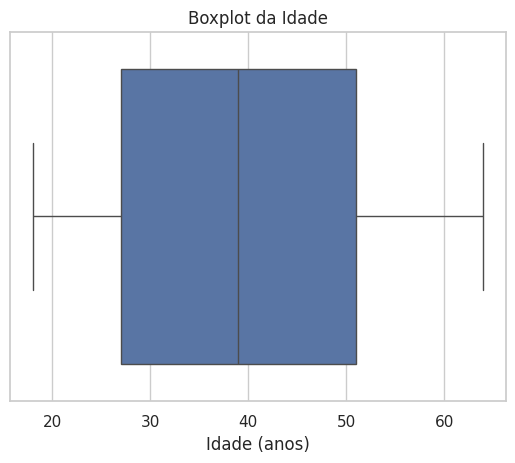

In [ ]:
# 1. Histograma e Boxplot para 'age'
plt.figure()
sns.histplot(df['age'], kde=True)
plt.title('Distribuição da Idade')
plt.xlabel('Idade (anos)')
plt.ylabel('Frequência')
plt.show()

print("\n")

plt.figure()
sns.boxplot(x=df['age'])
plt.title('Boxplot da Idade')
plt.xlabel('Idade (anos)')
plt.show()

• Distribuição de Custos ('charges'): O histograma de 'charges' confirma a forte assimetria positiva, com a maioria dos custos concentrada em valores mais baixos e uma longa cauda à direita, indicando a presença de indivíduos com custos muito elevados. O boxplot de 'charges' evidencia claramente a existência de muitos outliers na parte superior, reforçando a observação da assimetria.

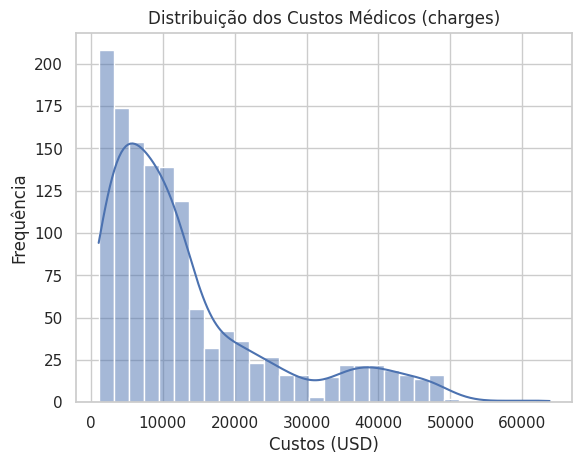

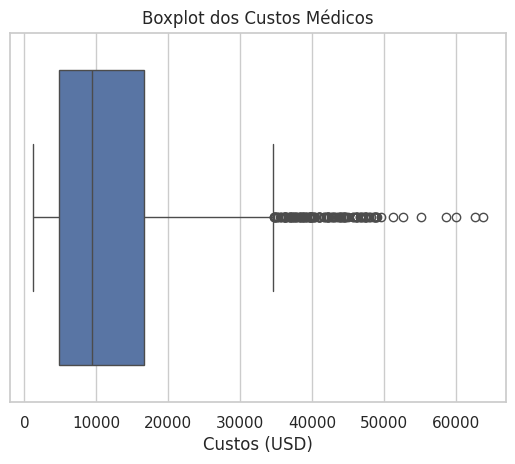

In [ ]:
# 2. Histograma e Boxplot para 'charges'

plt.figure()
sns.histplot(df['charges'], kde=True)
plt.title('Distribuição dos Custos Médicos (charges)')
plt.xlabel('Custos (USD)')
plt.ylabel('Frequência')
plt.show()

print("\n")

plt.figure()
sns.boxplot(x=df['charges'])
plt.title('Boxplot dos Custos Médicos')
plt.xlabel('Custos (USD)')
plt.show()

• Frequência por Gênero ('sex'): O gráfico de barras para 'sex' mostra uma distribuição quase igual entre homens e mulheres no dataset, com uma leve predominância masculina.

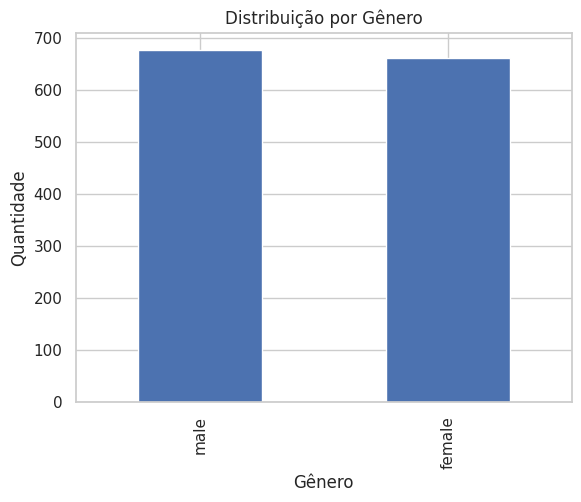

In [ ]:
# 3. Gráfico de Barras para 'sex' (Categórica)
plt.figure()
df['sex'].value_counts().plot(kind='bar')
plt.title('Distribuição por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.show()

• Relação Idade vs Custos ('age' vs 'charges'): O gráfico de dispersão revela uma correlação positiva entre idade e custos médicos: quanto mais velho o indivíduo, maiores tendem a ser os custos. É possível observar agrupamentos de pontos que sugerem a influência de outras variáveis (como o status de fumante, que não foi incluído nesta análise, mas é conhecido por impactar fortemente os custos de seguro).

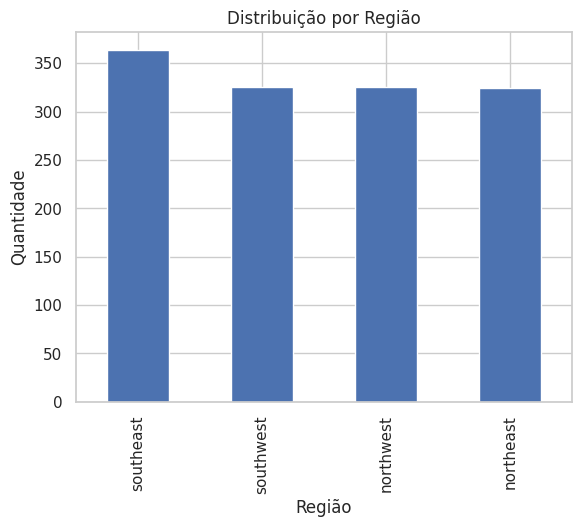

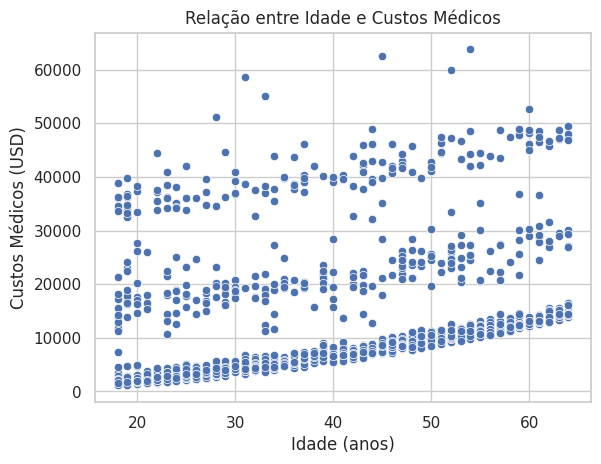

In [ ]:
# 4. Relação entre duas quantitativas: Dispersão (age vs charges)
plt.figure()
df['region'].value_counts().plot(kind='bar')
plt.title('Distribuição por Região')
plt.xlabel('Região')
plt.ylabel('Quantidade')
plt.show()

print("\n")

plt.figure()

sns.scatterplot(x=df['age'], y=df['charges'])

plt.title('Relação entre Idade e Custos Médicos')
plt.xlabel('Idade (anos)')
plt.ylabel('Custos Médicos (USD)')
plt.show()

• Custos Médicos por Região ('region' vs 'charges'): O boxplot mostra que, embora haja sobreposição, a região 'southeast' (sudeste) apresenta uma mediana de custos ligeiramente mais alta e uma maior dispersão (amplitude do box e presença de outliers) em comparação com as outras regiões. Isso pode indicar fatores regionais que influenciam os gastos com saúde.

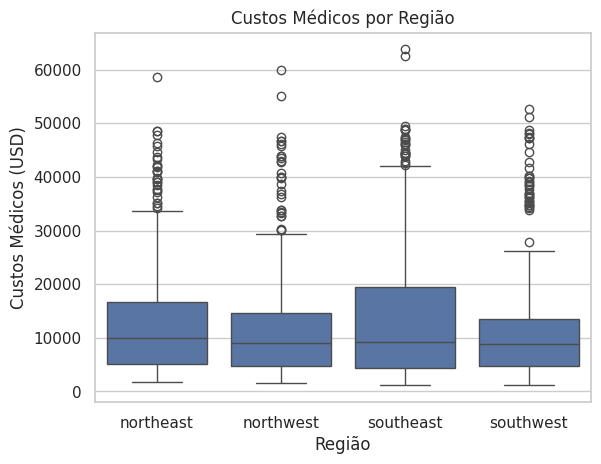

In [ ]:
# Segunda figura para relação Categórica x Quantitativa

plt.figure()

sns.boxplot(
    x='region',
    y='charges',
    data=df,
    order=sorted(df['region'].unique())
)

plt.title('Custos Médicos por Região')
plt.xlabel('Região')
plt.ylabel('Custos Médicos (USD)')
plt.show()

Etapa 4 — Interpretação

O que o conjunto de dados descreve?

O conjunto de dados descreve os custos médicos individuais faturados pelo seguro de saúde nos Estados Unidos, juntamente com características demográficas e de estilo de vida dos beneficiários, como idade, gênero, índice de massa corporal (BMI), número de filhos, status de fumante e região de residência. Para esta análise, focamos em idade, custos, gênero e região.

Quais padrões principais aparecem?

Os padrões principais revelam que a idade é um fator importante nos custos médicos, com uma tendência de aumento dos gastos conforme a idade avança. A distribuição dos custos médicos é altamente assimétrica, indicando que a maioria das pessoas tem custos baixos, mas uma minoria significativa incorre em despesas muito elevadas. Em termos de gênero e região, a distribuição é relativamente equilibrada, embora a região sudeste (southeast) se destaque por apresentar custos médios e máximos ligeiramente superiores.

Existe assimetria/outliers? O que isso sugere?

Sim, há uma forte assimetria positiva na distribuição dos custos médicos ('charges'), acompanhada pela presença de muitos outliers (valores extremamente altos). Isso sugere que o sistema de saúde ou as condições de saúde da população resultam em uma concentração de custos em um pequeno grupo de indivíduos. Esses outliers podem representar casos de doenças crônicas, acidentes graves, tratamentos caros ou condições de saúde complexas que exigem intervenções médicas prolongadas e de alto custo. A análise desses outliers seria crucial para entender os fatores que impulsionam os gastos mais elevados.

Qual comparação por grupos foi mais relevante?

A comparação mais relevante por grupos foi a dos custos médicos por região. Embora as diferenças não sejam drásticas, a região sudeste (southeast) consistentemente mostra custos médios e uma dispersão maior em relação às outras regiões. Isso pode indicar variações regionais em políticas de saúde, prevalência de certas doenças, acesso a serviços médicos ou até mesmo fatores socioeconômicos que influenciam os gastos com saúde.

Outros comentários pertinentes

É importante notar que, embora a idade mostre uma correlação clara com os custos, o gráfico de dispersão 'age' vs 'charges' exibe faixas distintas de custos para a mesma idade. Isso sugere que outras variáveis presentes no dataset (como o status de fumante, que é um preditor muito forte de custos médicos) têm um impacto significativo e interagem com a idade para determinar o nível de despesa. Uma análise multivariada aprofundada seria o próximo passo lógico para desvendar essas interações e construir um perfil mais completo dos clientes.

